## Manuscript
In the paper Gowda et al Cell 2022 the authors measured the dynamics of nitrate (A) and nitrite (I) in time for a library of nearly 70 bacterial strains. These bacteria were isolated from soils in corn and soybean fields near Urbana, IL.  Each one of these strains was whole genome sequenced and their metabolic phenotypes were measured as described below. The goal of this study was to relate genotypes (genes these bacteria have) to the metabolic activity (function) of communities of strains.  As part of this process we used a consumer resource modeling formalism.

### The measurement and analysis

* Each one of these strains was grown in a defined minimal medium in an anaerboic chamber (Nitrogen gas atmosphere) in small volumtes (1 milliliter). This medium supplied them with (1) a carbon source (succinate) (2) an electron accceptor (nitrate, A or nitrite, I), and a nitrogen source (ammonium). The carbon and nitrogen sources are in excess so they can be assumed to never run out.

* At the beginning of an experiment a small initial density (quantified by optical density; OD) of cells is added to this medium in anaerobic conditions. These cells then begin growing and consuming nitrate and nitrite. At a series of logarithmically spaced time intervals Karna manually samples a small volume from each well and measures the nitrate and nitrite concentration. This gives him a time series of nitrate and nitrite.  At the end of the growth Karna again measures the OD which is proporational to the biomass.  The difference between the starting and ending optical density tells him how much biomass was created during growth.

* For each strain in the library Karna repeats the experiment above in 5 different initial conditions which vary in the starting cell density (OD) and the initial supply of nitrate and nitrite.

* To the resulting data Karna globally (meaning all five initial conditions at once) the following model (Figure 3B):
$$
\frac{dx}{dt} = \bigg( \gamma_Ar_A \frac{A}{K_A + A} + \gamma_Ir_I \frac{I}{K_I + I}\bigg)x
$$

$$
\frac{dA}{dt} = -r_A x\frac{A}{K_A + A}
$$

$$
\frac{dI}{dt} = \bigg( r_A \frac{A}{K_A + A} - r_I \frac{I}{K_I + I} \bigg)x
$$

* This is the model for a Nar/Nir strain. For a Nar strain (only nitrate reduction) $r_I = 0$, $\gamma_I=0$. For a Nir strain $r_A = 0$, $\gamma_A = 0$. The parameters have the following units.

** $x$ ~ [OD]
<br>
** $A$ and $I$ ~ [mM] -- concentrations of electron acceptors.
<br>
** $r_A$ and $r_I$ ~ [mM/OD/h] -- these are rates.
<br>
** $K_A$ and $K_I$ ~ [mM] -- these are affinities.
<br>
$\gamma_A$ and $\gamma_I$ ~ [OD/mM] -- note $\gamma$ is a biomass yield term it is telling us how much biomass each strain produces per unit nutrients (A or I).

* Some brief notes on how this inference was done. First, to measure the $\gamma$ parameters Karna measures the change in OD when cells consume either A or I or both. He then just computes how much OD/nutrient is produced (via linear regression).  Second, Karna fixes the $K_*$ parameters (where $*$ is $A$ or $I$) to a small values (0.001 or lower) because these values cannot be inferred from our data (you will explore why below). Finally, Karna uses an optimization algorithm to search for the values of $r_A$ and $r_I$ that best fit the data.  Therefore, for a Nar/Nir strain there are four parameters ($r_A$, $r_I$, $\gamma_A$, and $\gamma_I$).


### Code that is provided

* We provide you with a library of functions that perform analyses on these raw data.  You need not do any of the parameter fitting or data wrangling on your own.  That said, you'll need to familiarize yourself with how the code Karna (and Kyle) have written to be able to answer the questions below.  The primary file for you to look at is the denitfit.py file which defines a class and a set of methods that operate on that class.  

* There are examples of basic operations using this library provided as well as a series of questions for you to answer.

### Step 1: fit the raw data (for illustration purposes only), pfit.npz contains the results of this fitting.

In [3]:
#below is code to fit denitrification data for a single strain.  You do not need to
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import denitfit as dn
from lmfit import Parameters, report_fit
import pickle
from os.path import exists

plt.rc('text', usetex=True)

monocultures = pickle.load(open( "monocultures.pkl", "rb" ))

#extract strain IDs and phenotypes from monocultures object
strain_id = []
phenotype = []
for i in range(0,len(monocultures)):
    strain_id.append(monocultures[i][0].ID)
    phenotype.append(monocultures[i][0].phen)
print(strain_id)
#FIT METABOLITE DATA
if exists('pfit.npz'): #since it takes a while to fit all monoculture data, save it and load subsequently
#if False:
    pfit = np.load('pfit.npz')['arr_0']
else:
    #pfit = np.zeros((4,len(monocultures)))
    pfit = np.zeros((6,len(monocultures),1)) #need the third dimension, which represents number of strains,  for the call to plotDenitFit
    #print(np.shape(pfit))
    for i in range(0,len(monocultures)):
        params = Parameters()
    #for i in range(4):
        if monocultures[i][0].phen == 'Nar/Nir':
            params.add('rA', value=10.0, min=0, max=30,vary=True,brute_step=5)
            params.add('rI', value=10.0, min=0, max=25,vary=True,brute_step=5)
        elif monocultures[i][0].phen == 'Nar':
            params.add('rA', value=10.0, min=0, max=30,vary=True,brute_step=5)
            params.add('rI', value=0.0, min=0, max=25,vary=False)
        elif monocultures[i][0].phen == 'Nir':
            params.add('rA', value=0.0, min=0, max=30,vary=False)
            params.add('rI', value=10.0, min=0, max=25,vary=True,brute_step=5)

        #Fit yield parameters
        gamA,gamI,gam_se,r2 = dn.fitYields(monocultures[i]) #fits across different initial conditions

        if gamA<0:
            gamA = 0
        if gamI<0:
            gamI = 0
        if gam_se[0,0]<0:
            gamA = 0
        if gam_se[1,0]<0:
            gamI = 0

        #Fit rate parameters
        params.add('kA', value=1e-2, min=1e-3, max=1e1,vary=False) #fix affinity parameters as in paper. can also allow these to vary
        params.add('kI', value=1e-2, min=1e-3, max=1e1,vary=False)
        params.add('gamA', value=gamA, min=0, max=0.04,vary=False)
        params.add('gamI', value=gamI, min=0, max=0.04,vary=False)
        result = dn.fitRates(params,monocultures[i])


        #format fit parameters in array
        pfit[0,i,0]=result.params['rA'].value
        pfit[1,i,0]=result.params['rI'].value
        pfit[2,i,0]=result.params['kA'].value
        pfit[3,i,0]=result.params['kI'].value
        pfit[4,i,0]=result.params['gamA'].value
        pfit[5,i,0]=result.params['gamI'].value

    np.savez('pfit', pfit)


[np.str_('PAR19367'), np.str_('PDM18'), np.str_('PDM20'), np.str_('PDM13'), np.str_('RLT01'), np.str_('PDM21'), np.str_('PNT03'), np.str_('VRV01'), np.str_('PDM12'), np.str_('PNT02'), np.str_('BKH01'), np.str_('ENS09'), np.str_('PDM07'), np.str_('PDM08'), np.str_('PDM03'), np.str_('PDM02'), np.str_('PDM01'), np.str_('PDM10'), np.str_('PDM09'), np.str_('PNT01'), np.str_('PDM19'), np.str_('ENS08'), np.str_('ENS07'), np.str_('PDM23'), np.str_('ENS06'), np.str_('ENS05'), np.str_('STM01'), np.str_('DLF01'), np.str_('CMM01'), np.str_('ENS04'), np.str_('PAR01'), np.str_('ENS03'), np.str_('PXM03'), np.str_('PDM17'), np.str_('ENS10'), np.str_('PDM22'), np.str_('PDM14'), np.str_('XNM01'), np.str_('ENS02'), np.str_('ENS11'), np.str_('PDM16'), np.str_('ENS01'), np.str_('PXM02'), np.str_('PXM01'), np.str_('PDM04'), np.str_('PDM06'), np.str_('PXM04'), np.str_('ACM01'), np.str_('ARZ01'), np.str_('ACM03'), np.str_('PDM05'), np.str_('AGB01'), np.str_('PDM15'), np.str_('RHZ01'), np.str_('ACM02'), np.str

ValueError: too many values to unpack (expected 4)

# Part 1: analyzing single strain phenotypes -- plotting data with fits
* Now that we have the fits we can look at the data.  Below is a cell that plots the data (points) and fit for a single strain in the library.

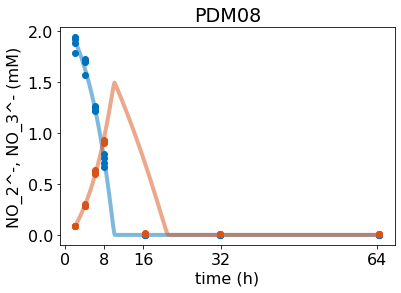

In [ ]:
#here the monoculture fits are plotted
monocultures = pickle.load(open( "monocultures.pkl", "rb" ))
# note that you also need pfit for this to work.
i = 13 # this is the strain index
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite.  This refers to the initial condition where only nitrate is supplied at a concentration of 2mM.

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = 1

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]]) # this is a vector of the parameters for this strain.
    # the order of parameters is rA, rI, KA, KI, gamA, gamI
dn.plotDenitFit(p,monocultures[i][j],n_strains) # this is a function within denitfit.py that does the plotting for you.  You may inspect the source
# to see how this is being accomplished.
plt.title(monocultures[i][j].ID);

You can also use this code to change the value of a parameter in the model and plot the results.  Below is an example:

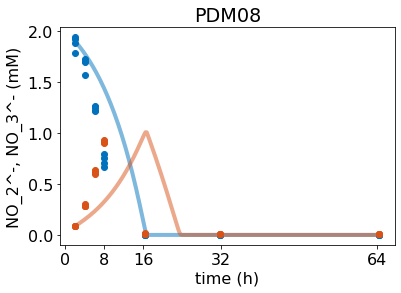

In [ ]:
#see effect of changing parameters
monocultures = pickle.load(open( "monocultures.pkl", "rb" ))

i = 13
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = 1

#first, get fit parameters
rA=pfit[0,i,0]
rI=pfit[1,i,0]
kA=pfit[2,i,0]
kI=pfit[3,i,0]
gamA=pfit[4,i,0]
gamI=pfit[5,i,0]

#next, modify parameters if desired
rA = rA/2.0

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)
plt.title(monocultures[i][j].ID);

Assessing the quality of a fit can be done as follows:

In [ ]:
rmse_out = dn.RMSE(p,monocultures[i][j],n_strains)
print(monocultures[i][j])
print(rmse_out) # root mean squared error

0.3912155181835907


### Question 1: Why are we justified in not fitting the affinity $K_A$ and $K_I$ parameters but instead fixing them to the same value for all strains in the library?

* Pick a strain in the library (any strain is fine).
* Change the value of $K_A$ and $K_I$ and plot the difference.  How much do you have to change affinities to affect the plot in any substantial way?
* Compute the RMSE (root mean squared error) of the fit over a range of both affinity parameters and plot RMSE vs $K_*$ for both $K_A$ and $K_I$.

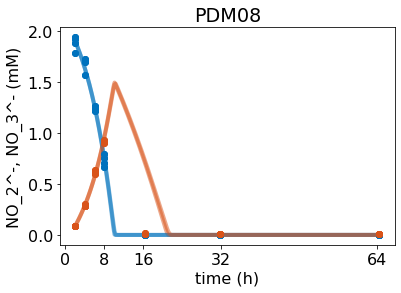

In [ ]:
#see effect of changing parameters
monocultures = pickle.load(open( "monocultures.pkl", "rb" ))

i = 13
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = 1

#first, get fit parameters
rA=pfit[0,i,0]
rI=pfit[1,i,0]
kA=pfit[2,i,0]
kI=pfit[3,i,0]
gamA=pfit[4,i,0]
gamI=pfit[5,i,0]

#next, modify parameters if desired
kA = pfit[2,i,0]
kI = pfit[2,i,0]

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)


#first, change by a factor of 2: no noticeable difference
kA = 2*kA
kI = 2*kI
p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)
plt.title(monocultures[i][j].ID);

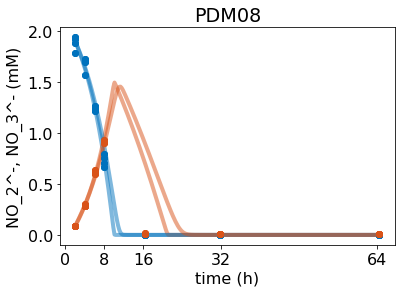

In [ ]:
#next, change by a factor of 10: difference is noticeable but small

i = 13
j = 0

kA = pfit[2,i,0]
kI = pfit[2,i,0]

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)

kA = 10*kA
kI = 10*kI
p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)
plt.title(monocultures[i][j].ID);

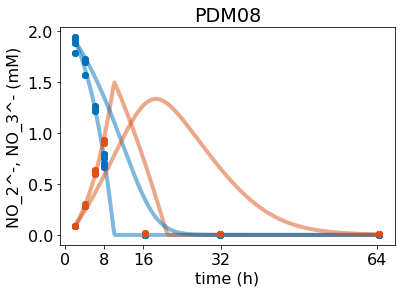

In [ ]:
#next, change by a factor of 100: difference is large

i = 13
j = 0

kA = pfit[2,i,0]
kI = pfit[2,i,0]

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)

kA = 100*kA
kI = 100*kI
p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)
plt.title(monocultures[i][j].ID);

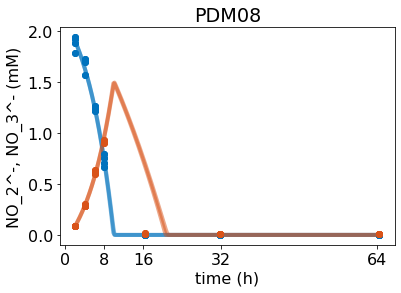

In [ ]:
#Note that a decrease in affinities does not change the dynamics

i = 13
j = 0

kA = pfit[2,i,0]
kI = pfit[2,i,0]

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)

kA = kA/1000.0
kI = kI/1000.0
p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    #p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
    p.append([rA,rI,kA,kI,gamA,gamI])
dn.plotDenitFit(p,monocultures[i][j],n_strains)
plt.title(monocultures[i][j].ID);

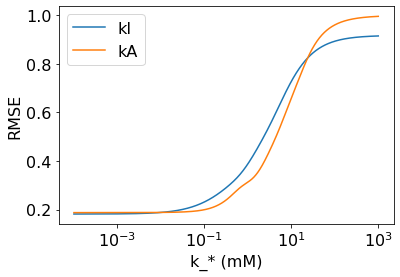

In [ ]:
#finally, plot RMSE as a function of kI and kA

i = 13
j = 0

rA=pfit[0,i,0]
rI=pfit[1,i,0]
kA=pfit[2,i,0]
kI=pfit[3,i,0]
gamA=pfit[4,i,0]
gamI=pfit[5,i,0]
n_strains = 1
num_pts = 1000
kAs = np.logspace(-4, 3, num_pts)
kIs = np.logspace(-4, 3, num_pts)
rmses_kA = []
rmses_kI = []
for k in range(len(kAs)):
    p = []
    kA = kAs[k]
    p.append([rA,rI,kA,kI,gamA,gamI])
    rmses_kA.append(dn.RMSE(p,monocultures[i][j],n_strains))

rA=pfit[0,i,0]
rI=pfit[1,i,0]
kA=pfit[2,i,0]
kI=pfit[3,i,0]
gamA=pfit[4,i,0]
gamI=pfit[5,i,0]
for k in range(len(kIs)):
    p = []
    kI = kIs[k]
    p.append([rA,rI,kA,kI,gamA,gamI])
    rmses_kI.append(dn.RMSE(p,monocultures[i][j],n_strains))


plt.semilogx(kIs, rmses_kI, label = 'kI')
plt.semilogx(kAs, rmses_kA, label = 'kA')
plt.legend()
plt.ylabel([0,1.1])
plt.xlabel('k_* (mM)')
plt.ylabel('RMSE')
plt.show()



### Question 2: What controls the transient accumulation of nitrite?
* You will notice in the two examples above that the strain PDM08 (index 13) allows nitrite to accumulate in the extracellular medium before later reducing it.  In contrast strain ENS10 (index 34) does not.  Why is this the case?  You rationale should be in terms of the parameters of the model.  

In [ ]:
#print reduction rates for PDM08:
i = 13
j = 0

rA=pfit[0,i,0]
rI=pfit[1,i,0]
print('For PDM08, rA is ' + str(rA))
print('For PDM08, rI is ' + str(rI))
print('')
#next, print reduction rates for ENS10:
i = 34
j = 0

rA=pfit[0,i,0]
rI=pfit[1,i,0]
print('For ENS10, rA is ' + str(rA))
print('For ENS10, rI is ' + str(rI))

For PDM08, rA is 10.763441260557094
For PDM08, rI is 2.739644404553432

For ENS10, rA is 4.122556766866153
For ENS10, rI is 5.578830507548979


KC SOLUTION: PDM08 accumulates nitrite because rA > rI (assuming that kA~kI << A0). This means that nitrate is reduced to nitrite more quickly than nitrite is reduced to nitric oxide. Similarly, ENS10 does not accumulate nitrite because rI > rA. This means that nitrite reduced more quickly than it is produced by the reduction of nitrate.

### Question 3: Are there any apparent contraints on the phenotypes?
* As we will discuss later in the course it is sometimes observed that phenotypes are subjected to trade-offs where an increase in one trait comes at the expense of another.  For example, it is sometimes proposed that growth rates and biomass yields per unit nutrient are subjected to a tradeoff (e.g. higher yielding strains grow more slowly and the converse).  Is there any evidence in these data to support the presence of such a trade-off?  To answer this question you will want to make a plot of yields ($\gamma_*$) vs rates ($r_*$) and look for a correlation between the two.  

Text(0.5, 1.0, 'gamA-rA: Pearsons r = 0.15, p = 0.3')

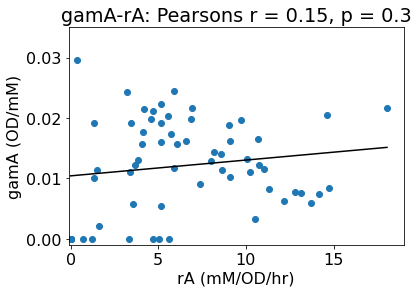

In [ ]:
#first plot rA vs gamma_A, calculate Pearson's correlation, and plot a linear regression
import scipy.stats

rAs = []
gamAs = []
for i in range(len(pfit[0,:,0])):
    rAs.append(pfit[0,i,0])
    gamAs.append(pfit[4,i,0])

#calculate Pearson's r
r, p = scipy.stats.pearsonr(rAs, gamAs)

#perform linear regression
results = scipy.stats.linregress(rAs, gamAs)

#plot result
plt.scatter(rAs, gamAs)
rAs_for_regression = np.linspace(min(rAs), max(rAs))
plt.plot([min(rAs), max(rAs)], [min(rAs)*results.slope+results.intercept, max(rAs)*results.slope+results.intercept], 'k')
plt.ylim([-0.001,0.035])
plt.xlim([-0.1,19])
plt.xlabel('rA (mM/OD/hr)')
plt.ylabel('gamA (OD/mM)')
plt.title('gamA-rA: Pearsons r = ' + str(round(r,2))+ ', p = '+str(round(p,1)))

Text(0.5, 1.0, 'gamI-rI: Pearsons r = 0.36, p = 0.004')

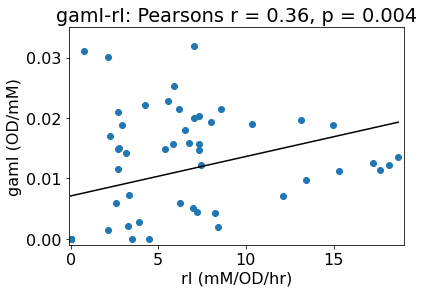

In [ ]:
#now repeat for I
import scipy.stats

rIs = []
gamIs = []
for i in range(len(pfit[0,:,0])):
    rIs.append(pfit[1,i,0])
    gamIs.append(pfit[5,i,0])

#calculate Pearson's r
r, p = scipy.stats.pearsonr(rIs, gamIs)

#perform linear regression
results = scipy.stats.linregress(rIs, gamIs)

#plot result
plt.scatter(rIs, gamIs)
plt.plot([min(rIs), max(rIs)], [min(rIs)*results.slope+results.intercept, max(rIs)*results.slope+results.intercept], 'k')
plt.ylim([-0.001,0.035])
plt.xlim([-0.1,19])
plt.xlabel('rI (mM/OD/hr)')
plt.ylabel('gamI (OD/mM)')
plt.title('gamI-rI: Pearsons r = ' + str(round(r,2))+ ', p = '+str(round(p,3)))

KC SOLUTION: A negative correlation would be evidence of a tradeoff, so there is not evidence of a rate-yield tradeoff in these data. For growth using nitrite, there even appears to be a small but statistically significant _positive_ correlation between rate and yield.

# Part 2: Predicting and simulating community dynamics
* There is a .pkl file for paircultures (communities of two strains) and cocultures (communities of >2 strains).  
* Below is an example of a prediction and data comparison for a two strain community.

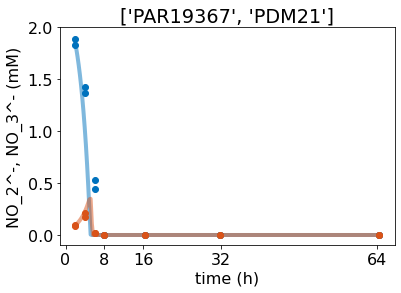

In [ ]:
#below is an example that predicts the pair culture at index 1 and compares it to the data.
paircultures = pickle.load(open( "paircultures.pkl", "rb" ))

i = 1 #pair cultures index
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = len(paircultures[i][j].ID) # in this case there are two strains
p = []
for k in range(0,n_strains): # so this loop will run twice.
    idx = strain_id.index(paircultures[i][j].ID[k])
    p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
dn.plotDenitFit(p,paircultures[i][j],n_strains) # note that this function is actually integrating the ODEs in order to draw the curves on this plot
plt.title(paircultures[i][j].ID);

### Question 4: Why does nitrite accumulate in co-cultures?
* Look at Figure 6A in the manuscript.  The fourth row of plots shows a monoculture and co-culture comparison between ENS09 and PAR01.  Recreate this row (all three panels) using the code provided in this notebook.  Examine the parameters of these strains, why does nitrite accumulate in co-culture?  Isn't it amazing how well this prediction works!!!???

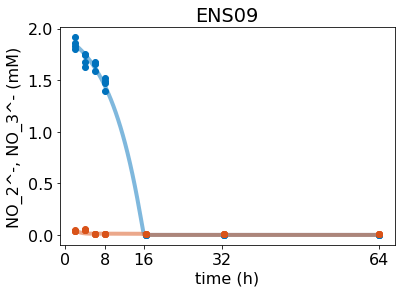

In [ ]:
#first, identify the indices corresponding to these strains:

for i in range(len(monocultures[:])):
    if monocultures[i][0].ID == 'ENS09':
        ens09 = i
    elif monocultures[i][0].ID == 'PAR01':
        par01 = i

#Now plot the ensifer monoculture
i = ens09 # this is the strain index
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite.  This refers to the initial condition where only nitrate is supplied at a concentration of 2mM.

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = 1

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]]) # this is a vector of the parameters for this strain.
    # the order of parameters is rA, rI, KA, KI, gamA, gamI
dn.plotDenitFit(p,monocultures[i][j],n_strains) # this is a function within denitfit.py that does the plotting for you.  You may inspect the source
# to see how this is being accomplished.
plt.title(monocultures[i][j].ID);

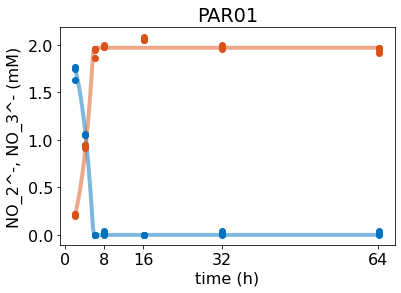

In [ ]:
#Now plot the par monoculture
i = par01 # this is the strain index
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite.  This refers to the initial condition where only nitrate is supplied at a concentration of 2mM.

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = 1

p = []
for k in range(0,n_strains):
    idx = strain_id.index(monocultures[i][j].ID)
    p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]]) # this is a vector of the parameters for this strain.
    # the order of parameters is rA, rI, KA, KI, gamA, gamI
dn.plotDenitFit(p,monocultures[i][j],n_strains) # this is a function within denitfit.py that does the plotting for you.  You may inspect the source
# to see how this is being accomplished.
plt.title(monocultures[i][j].ID);

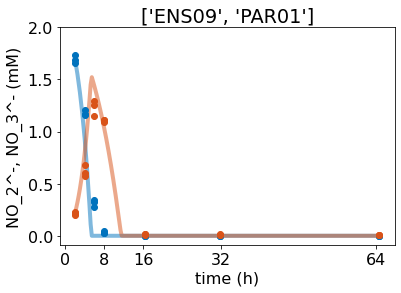

In [ ]:
#Finally, plot coculture
#first, get correct index
for i in range(len(paircultures[:])):
    if 'ENS09' in paircultures[i][0].ID and 'PAR01' in paircultures[i][0].ID:
        pair_idx = i

#next, plot coculture
i = pair_idx #pair cultures index
j = 0 #experiment index; 0 is 2 mM nitrate and 1 is 2 mM nitrite

#grab the parameters that were just fit to monocultures by looking up strain IDs
n_strains = len(paircultures[i][j].ID) # in this case there are two strains
p = []
for k in range(0,n_strains): # so this loop will run twice.
    idx = strain_id.index(paircultures[i][j].ID[k])
    p.append([pfit[0,idx],pfit[1,idx],1e-2,1e-2,pfit[4,idx],pfit[5,idx]])
dn.plotDenitFit(p,paircultures[i][j],n_strains) # note that this function is actually integrating the ODEs in order to draw the curves on this plot
plt.title(paircultures[i][j].ID);

In [ ]:
#print reduction rates for ENS09:
i = ens09
j = 0

rA=pfit[0,i,0]
rI=pfit[1,i,0]
print('For ENS09, rA is ' + str(rA))
print('For ENS09, rI is ' + str(rI))
print('')
#next, print reduction rates for PAR01:
i = par01
j = 0

rA=pfit[0,i,0]
rI=pfit[1,i,0]
print('For PAR01, rA is ' + str(rA))
print('For PAR01, rI is ' + str(rI))

For ENS09, rA is 4.059985776248462
For ENS09, rI is 7.3405515356635895

For PAR01, rA is 18.04938927697495
For PAR01, rI is 0.0


KC SOLUTION: In coculture with equal relative abundances of each strain (and again assuming that kA ~ kI << A0), the nitrite will accumulate when rA_1+rA_2 > rI_1+rI_2. This is because nitrite is produced from nitrate more quickly than it is consumed. Since this inequality holds for ENS09 and PAR01, a coculture of these strains accumulates nitrate.

It is amazing and the Kuehn lab is amazing for discovering it! [I think you should take points off if they don't say this.]

# Question 5: Who can co-exist with whom? (Simulation, not data)
* We now have phenotypes (parameters of the model) for many strains and we have shown that in most cases (except Nar + Nir) that this model predicts the metabolite dynamics in pair-cultures.  Here we look at the question of whether two strains can grow together without one outcompeting the other.

* We will consider co-existence in a 'serial dilution' condition where cells are grown for 64 hours (as above) and then diluted (meaning densities drop by a fixed factor) into fresh medium where they can grow again. This constitutes one round of serial dilution.  To test for coexistence we (in silico) repeat these rounds of serial dilution over and over again and look to see whether the abundances of both strains are stable from cycle to cycle (or whether one of two strains is going to zero).

* Question 5.1: Choose at least ~ 100 - 200 pairs of strains from the monoculture dataset and use their traits (parameters) to run a simulation of each pair in serial dilution co-culture.  Devise a way to determine if the strains are coexisting after a large number of dilutions (or not coexisting).  For example, when the serial dilution is stable, the abundances should no longer change from round to round.  Make a plot indicating what types of pairs coexist. (Ignore the issues with Nar and Nir strains discussed in the paper and just assume the model works for paircultures of Nar and Nir).

* [extra credit] In class we showed that two resources support only two species when resources are supplied constantly in time.  Here we have just two resources (A and I).  In the serial dilution regime (resources are not constant in time),

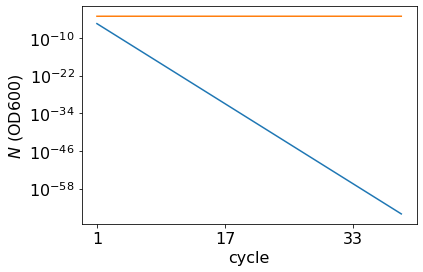

In [ ]:
#below is an example of a serial enrichment simulation for randomly generated strains.
#you should modify this to answer the questions above

#brute force randomly generate phenotypes. You should change this!
n_strains = 2
r_lim = [0,20]
gam_lim = [0,0.035]

p = []
for i in range(0,n_strains): # setup the parameters -- YOU WILL HAVE TO TWEAK THIS!!!!
    rA = np.random.uniform(low=r_lim[0],high=r_lim[1])
    rI = np.random.uniform(low=r_lim[0],high=r_lim[1])
    gamA = np.random.uniform(low=gam_lim[0],high=gam_lim[1])
    gamI = np.random.uniform(low=gam_lim[0],high=gam_lim[1])
    p.append([rA,rI,0.01,0.01,gamA,gamI])

#simulate multiple cycles of serial enrichment
n_cycles = 40 # number of rounds
dilution_factor = 100; # factor by which cells are diluted from one round to the next
nk = np.zeros((n_cycles,n_strains))
nk[0,:] = 0.0001

for k in range(1,n_cycles):
    yh = dn.denitODE(np.append(nk[k-1,:],[2,0]),[0,64],p,n_strains) #integrate the model
    nk[k,:] = yh[1][0:n_strains]/dilution_factor

for i in range(0,n_strains):
    plt.plot(range(1,n_cycles),nk[1:,i])
    ax = plt.gca()
    plt.xticks(range(1,n_cycles+1,16));
    plt.ylabel('$N$ (OD600)');
    plt.xlabel('cycle');
    ax.set_yscale('log')

# YOU WILL HAVE TO WRITE CODE TO DETERMINE WHETHER OR NOT STRAINS ARE COEXISTING OR NOT.

ENS02 outcompetes PDM10
PDM22 and PAR01 coexist
PDM08 outcompetes PXM01
CMM01 outcompetes PDM12
PAR01 and ENS06 coexist
PDM09 outcompetes PXM01
PDM23 outcompetes XNM01
PDM06 outcompetes ACV01
DLF01 outcompetes PDM12
PAR19367 outcompetes ENS02
ARZ01 outcompetes PDM15
PDM21 outcompetes RHZ01
ENS05 outcompetes ENS10
ACM04 outcompetes CMM02
PDM19 outcompetes BKH01
PDM04 outcompetes ENT01
PDM18 outcompetes RHZ01
ARZ01 outcompetes AGB01
ENS05 outcompetes PXM03
ACM04 outcompetes BKH01
ENS11 outcompetes DLF01
PXM02 and PDM13 do not reach steady state
PAR01 and AGB01 coexist
ENT01 and PXM04 coexist
PDM03 outcompetes RHZ02
RHZ02 outcompetes PXM04
STM01 and PDM15 do not reach steady state
PDM23 outcompetes ACM04
ACV01 outcompetes PDM11
PDM01 outcompetes PDM08
PDM02 outcompetes DLF01
PDM18 outcompetes ENS01
ACV01 outcompetes PDM15
PAR19367 outcompetes PDM16
PDM01 outcompetes RHZ02
PDM10 outcompetes PDM09
PAR19367 outcompetes PDM08
ACV01 outcompetes PDM11
PAR19367 outcompetes ENS09
STM01 and PDM13 

PXM01 outcompetes PDM13
RLT01 outcompetes DLF01
ENS07 outcompetes RLT01
PDM04 outcompetes PXM02
STM01 and PDM11 do not reach steady state
BKH01 and PNT02 do not reach steady state
PDM10 outcompetes PXM03
PDM13 and DLF01 coexist
PAR19367 outcompetes BKH01
ARZ01 outcompetes STM01
RHZ02 outcompetes PXM01
PDM22 outcompetes VRV01
ENS02 outcompetes VRV01
ENS05 and ENS02 do not reach steady state
PDM10 outcompetes BKH01
ENS08 outcompetes ACM02
ENS09 outcompetes ENT01
PDM04 outcompetes PXM03
PDM19 outcompetes PDM03
ENS11 outcompetes PDM12
PDM20 outcompetes PDM15
PDM03 outcompetes PDM11
ACM04 outcompetes PDM16
PDM20 outcompetes PDM16
PDM20 outcompetes CMM01
ENS02 outcompetes BKH01
PDM23 outcompetes ACM01
ENS05 outcompetes ARZ01
BKH01 and PNT02 do not reach steady state
VRV01 outcompetes PNT01
ACM03 outcompetes PXM01
AGB01 and PDM16 do not reach steady state
ACM04 outcompetes XNM01
PDM01 outcompetes PDM11
PDM19 outcompetes ENS04
PDM11 and BKH01 do not reach steady state
PDM06 outcompetes ACM04
P

ENS02 and ENS05 do not reach steady state
ENS03 outcompetes DLF01
PDM03 outcompetes CMM01
PDM03 outcompetes PDM16
ENS01 outcompetes XNM01
PDM22 outcompetes ENS07
ENS08 outcompetes XNM01
ENS09 and PDM04 coexist
PDM22 outcompetes PDM06
XNM01 outcompetes PXM02
ENS02 outcompetes VRV01
PAR19367 outcompetes PXM03
RHZ02 outcompetes PNT03
DLF01 outcompetes PNT01
PDM20 outcompetes PDM03
ARZ01 outcompetes PNT01
PDM22 outcompetes STM01
PDM23 and PAR01 coexist
PDM21 outcompetes ENS05
ENS05 outcompetes PDM01
PDM22 outcompetes PXM01
PDM11 and PDM12 do not reach steady state
ENS01 outcompetes DLF01
PDM08 outcompetes CMM01
PDM09 outcompetes PNT01
PDM08 outcompetes BKH01
PDM23 outcompetes ENS11
ACM04 outcompetes PXM01
PDM17 outcompetes PDM05
PDM01 outcompetes PXM04
PDM20 outcompetes PDM18
ENS02 outcompetes PDM08


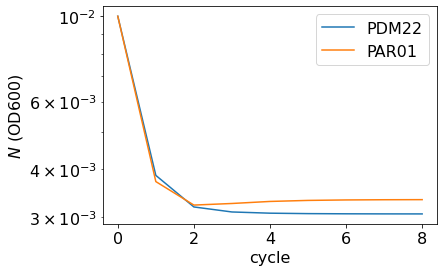

In [ ]:
#First, generate pairculture parameters
import random as rd
n_strains = 2
n_cos = 1000 #set number of cocultures
pair_indices = np.zeros((n_cos, n_strains))
#randomly select n_cos combinations of indices

for i in range(n_cos):
    idx_1 = rd.randint(0,len(monocultures[:])-1)
    idx_2 = rd.randint(0,len(monocultures[:])-1)
    #make sure that the indices aren't the same
    while idx_1 == idx_2:
        idx_2 = rd.randint(0,len(monocultures[:])-1)
    #check that the indices aren't the same
    if idx_1 == idx_2:
        raise NameError('indices are the same!')
    pair_indices[i,0] = idx_1
    pair_indices[i,1] = idx_2

#print(pair_indices)
#perform serial dilution
n_cycles = 100 #max cycles
dilution_factor = 10
nk = np.zeros((n_cos, n_cycles,n_strains))
nk[:,0,:] = 0.01 #initial abundances
ab_tol = 0.0001 #change in abundance at which we declare steady state
coexistence_threshold = 0.99 #threshold at which we declare coexistence
last_cycle = np.zeros(n_cos)

coexistence_indices = []
no_steady_state_indices = []
winner_indices = []
winning_strain = []

#classify strains by difference in growth rates \delta mu
co_delta_muA = []
co_delta_muI = []
win_1_delta_muA = []
win_1_delta_muI = []
win_2_delta_muA = []
win_2_delta_muI = []
for i in range(n_cos):
    p = []
    for j in range(n_strains):
        rA=pfit[0,int(pair_indices[i,j]),0]
        rI=pfit[1,int(pair_indices[i,j]),0]
        kA=pfit[2,int(pair_indices[i,j]),0]
        kI=pfit[3,int(pair_indices[i,j]),0]
        gamA=pfit[4,int(pair_indices[i,j]),0]
        gamI=pfit[5,int(pair_indices[i,j]),0]
        p.append([rA,rI,kA,kI,gamA,gamI])
    for k in range(1,n_cycles):
        yh = dn.denitODE(np.append(nk[i,k-1,:],[2,0]),[0,64],p,n_strains) #integrate the model
        nk[i,k,:] = yh[1][0:n_strains]/dilution_factor
        if k > 1:
            if np.abs(nk[i,k,0] - nk[i,k-1,0])/nk[i,k-1,0] < ab_tol or np.abs(nk[i,k,1] - nk[i,k-1,1])/nk[i,k-1,1] < ab_tol: #one rel. ab. is changing less than the tolerance
                #print('ended at cycle '+str(k))
                last_cycle[i] = k
                if nk[i,k,0]/(nk[i,k,1] + nk[i,k,0]) > coexistence_threshold:
                    print(monocultures[int(pair_indices[i,0])][0].ID + ' outcompetes ' + monocultures[int(pair_indices[i,1])][0].ID)
                    winner_indices.append(i)
                    winning_strain.append(0)
                    win_1_delta_muA.append(pfit[0,int(pair_indices[i,0]),0]*pfit[4,int(pair_indices[i,0]),0] - pfit[0,int(pair_indices[i,1]),0]*pfit[4,int(pair_indices[i,1]),0])
                    win_1_delta_muI.append(pfit[1,int(pair_indices[i,0]),0]*pfit[5,int(pair_indices[i,0]),0] - pfit[1,int(pair_indices[i,1]),0]*pfit[5,int(pair_indices[i,1]),0])
                elif nk[i,k,1]/(nk[i,k,1] + nk[i,k,0]) > coexistence_threshold:
                    print(monocultures[int(pair_indices[i,1])][0].ID + ' outcompetes ' + monocultures[int(pair_indices[i,0])][0].ID)
                    winner_indices.append(i)
                    winning_strain.append(1)
                    win_2_delta_muA.append(pfit[0,int(pair_indices[i,0]),0]*pfit[4,int(pair_indices[i,0]),0] - pfit[0,int(pair_indices[i,1]),0]*pfit[4,int(pair_indices[i,1]),0])
                    win_2_delta_muI.append(pfit[1,int(pair_indices[i,0]),0]*pfit[5,int(pair_indices[i,0]),0] - pfit[1,int(pair_indices[i,1]),0]*pfit[5,int(pair_indices[i,1]),0])


                else:
                    print(monocultures[int(pair_indices[i,0])][0].ID + ' and ' + monocultures[int(pair_indices[i,1])][0].ID + ' coexist')
                    coexistence_indices.append(i)
                    co_delta_muA.append(pfit[0,int(pair_indices[i,0]),0]*pfit[4,int(pair_indices[i,0]),0] - pfit[0,int(pair_indices[i,1]),0]*pfit[4,int(pair_indices[i,1]),0])
                    co_delta_muI.append(pfit[1,int(pair_indices[i,0]),0]*pfit[5,int(pair_indices[i,0]),0] - pfit[1,int(pair_indices[i,1]),0]*pfit[5,int(pair_indices[i,1]),0])


                #nk[i,k:,:] = nk[i,k,:] #set rest of cycles to asymptotic value
                break
        if k == n_cycles - 1:
            last_cycle[i] = k
            print(monocultures[int(pair_indices[i,0])][0].ID + ' and ' + monocultures[int(pair_indices[i,1])][0].ID + ' do not reach steady state') #this appears to happen when neither strain can grow fast enough to overcome the dilution rate
            no_steady_state_indices.append(i)
#plot to check that code above is working
i = coexistence_indices[0]
plt.plot(range(len(nk[i,:int(last_cycle[i]),0])), nk[i,:int(last_cycle[i]),0], label = monocultures[int(pair_indices[i,0])][0].ID)
plt.plot(range(len(nk[i,:int(last_cycle[i]),1])), nk[i,:int(last_cycle[i]),1], label = monocultures[int(pair_indices[i,1])][0].ID)
#plt.xlim([0,last_cycle[k]])
ax = plt.gca()
plt.legend()
#plt.xticks(range(1,n_cycles+1,16));
plt.ylabel('$N$ (OD600)');
plt.xlabel('cycle');
ax.set_yscale('log')

fraction coexisting = 0.047


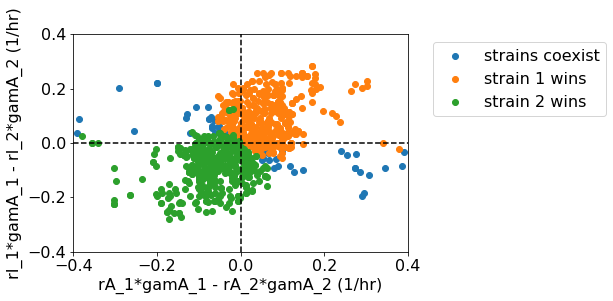

In [ ]:
#now, plot difference in growth rates for different outcomes

plt.scatter(co_delta_muA, co_delta_muI, label = 'strains coexist')
plt.scatter(win_1_delta_muA, win_1_delta_muI, label = 'strain 1 wins')
plt.scatter(win_2_delta_muA, win_2_delta_muI, label = 'strain 2 wins')
plt.vlines(0, -0.4, 0.4,linestyle = '--',  color = 'k', alpha = 1)
plt.plot([-0.4,0.4], [0,0],linestyle = '--',  color = 'k', alpha = 1)
plt.ylim([-0.4, 0.4])
plt.xlim([-0.4, 0.4])
f_co = float(len(co_delta_muA))/float(len(co_delta_muA)+len(win_1_delta_muA)+len(win_2_delta_muA) + len(no_steady_state_indices))
print('fraction coexisting = '+str(f_co))
plt.xlabel('rA_1*gamA_1 - rA_2*gamA_2 (1/hr)')
plt.ylabel('rI_1*gamA_1 - rI_2*gamA_2 (1/hr)')
plt.legend(bbox_to_anchor=(1.05, 1))

KC SOLUTION: We see that the outcome of serial dilution experiments is related to the relationship between growth rate \mu = r * \gamma. In particular, when one strain grows much more quickly on a certain resource and the other strain much more quickly on the other, they coexist. This is because each strain is able to effectively specialize on one of the resources.

If this is not the case, the strain with larger \muA+\muI will, in general,  outcompete the other strain.